<a href="https://colab.research.google.com/github/n-markov/cfd-offshore-wind-forecasting/blob/main/cfd_wind_forecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, requests, io

In [ ]:
BASE = "https://dp.lowcarboncontracts.uk/api/3/action"
DATASET = "actual-cfd-generation-and-avoided-ghg-emissions"

pkg = requests.get(f"{BASE}/package_show", params={"id": DATASET}).json()

if not pkg.get("success"):
    print("API error:", pkg)
else:
    for res in pkg["result"]["resources"]:
        print("Name:     ", res.get("name"))
        print("Format:   ", res.get("format"))
        print("ID:       ", res.get("id"))
        print("Datastore:", res.get("datastore_active"))
        print("URL:      ", res.get("url"))
        print("-" * 60)

Name:      Actual CfD Generation and avoided GHG emissions
Format:    JSON
ID:        37d1bef4-55d7-4b8e-8a47-1d24b123a20e
Datastore: True
URL:       https://dp.lowcarboncontracts.uk/datastore/dump/37d1bef4-55d7-4b8e-8a47-1d24b123a20e
------------------------------------------------------------
Name:      Actual CfD Generation and avoided GHG emissions
Format:    CSV
ID:        5279a55d-4996-4b1e-ba07-f411d8fd31f0
Datastore: False
URL:       https://dp.lowcarboncontracts.uk/dataset/8e8ca0d5-c774-4dc8-a079-347f1c180c0f/resource/5279a55d-4996-4b1e-ba07-f411d8fd31f0/download/actual_cfd_generation_and_avoided_ghg_emissions.csv
------------------------------------------------------------
Name:      Actual CfD Generation and avoided GHG emissions - Data Type Definitions
Format:    CSV
ID:        36b41864-162a-4ca2-9a55-4a8d47fc513c
Datastore: False
URL:       https://dp.lowcarboncontracts.uk/dataset/8e8ca0d5-c774-4dc8-a079-347f1c180c0f/resource/36b41864-162a-4ca2-9a55-4a8d47fc513c/download/a

In [ ]:
RID = "37d1bef4-55d7-4b8e-8a47-1d24b123a20e"

first = requests.get(f"{BASE}/datastore_search",
                     params={"resource_id": RID, "limit": 1}).json()
total = first["result"]["total"]
print("Total rows:", total)

rows, offset, limit = [], 0, 32000
while offset < total:
    batch = requests.get(f"{BASE}/datastore_search",
                         params={"resource_id": RID, "limit": limit,
                                 "offset": offset}).json()["result"]["records"]
    rows.extend(batch)
    offset += limit
    print(f"{len(rows):,} / {total:,}")

df = pd.DataFrame(rows)
print(df.shape)

Total rows: 116686
32,000 / 116,686
64,000 / 116,686
96,000 / 116,686
116,686 / 116,686
(116686, 14)


In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)
df.to_csv("/content/drive/MyDrive/cfd_generation_full.csv", index=False)

Mounted at /content/drive


In [ ]:
print(df.columns.tolist())
df.head(3)

['_id', 'Settlement_Date', 'CfD_ID', 'Name_of_CfD_Unit', 'Technology', 'Allocation_round', 'Reference_Type', 'CFD_Generation_MWh', 'Avoided_GHG_tonnes_CO2e', 'Strike_Price_GBP_Per_MWh', 'CFD_Payments_GBP', 'Avoided_GHG_Cost_GBP', 'Market_Reference_Price_GBP_Per_MWh', 'Weighted_IMRP_GBP_Per_MWh']


,_id,Settlement_Date,CfD_ID,Name_of_CfD_Unit,Technology,Allocation_round,Reference_Type,CFD_Generation_MWh,Avoided_GHG_tonnes_CO2e,Strike_Price_GBP_Per_MWh,CFD_Payments_GBP,Avoided_GHG_Cost_GBP,Market_Reference_Price_GBP_Per_MWh,Weighted_IMRP_GBP_Per_MWh
0,1,2024-08-20 00:00:00.0000000,AR2-TKN-203,Triton Knoll Offshore Wind Farm Phase 2,Offshore Wind,Allocation Round 2,IMRP,2333.9490,248.6023,102.0300,116500.3900,19681.8046,56.1563,52.1144
1,2,2025-11-05 00:00:00.0000000,AR4-CLH-710,Cleve Hill Solar Project,Solar PV,Allocation Round 4,IMRP,75.4460,7.9819,61.1600,-1352.1900,711.8570,78.1729,79.0827
2,3,2025-07-15 00:00:00.0000000,AR4-LYR-700,Layer,Solar PV,Allocation Round 4,IMRP,303.5930,32.1188,65.8900,-2396.8600,2542.9177,79.0000,73.7850


In [ ]:
df = df.drop(columns="_id")   # just a row counter added by the API

df = df.rename(columns={
    "Settlement_Date": "date",
    "CfD_ID": "unit",
    "Name_of_CfD_Unit": "name",
    "Technology": "tech",
    "Allocation_round": "round",
    "Reference_Type": "ref_type",
    "CFD_Generation_MWh": "gen",
    "Avoided_GHG_tonnes_CO2e": "ghg_t",
    "Strike_Price_GBP_Per_MWh": "strike",
    "CFD_Payments_GBP": "payment",
    "Avoided_GHG_Cost_GBP": "ghg_cost",
    "Market_Reference_Price_GBP_Per_MWh": "ref_price",
    "Weighted_IMRP_GBP_Per_MWh": "capture_price",
})

df["date"] = pd.to_datetime(df["date"].str[:10])
num_cols = ["gen", "ghg_t", "strike", "payment", "ghg_cost", "ref_price", "capture_price"]
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors="coerce")
df = df.sort_values(["unit", "date"]).reset_index(drop=True)
df.dtypes

,0
date,datetime64[ns]
unit,object
name,object
tech,object
round,object
ref_type,object
gen,float64
ghg_t,float64
strike,float64
payment,float64


In [ ]:
print("Rows:", len(df))
print("Date range:", df["date"].min().date(), "to", df["date"].max().date())
print("Units:", df["unit"].nunique())
print("Duplicate unit-days:", df.duplicated(subset=["date", "unit"]).sum())
print("Missing values:\n", df[num_cols].isna().sum())
print("Negative gen:", (df["gen"] < 0).sum())
print("\nTechnologies:\n", df["tech"].value_counts())
print("\nReference types:\n", df["ref_type"].value_counts())

Rows: 116686
Date range: 2016-06-30 to 2026-09-16
Units: 86
Duplicate unit-days: 0
Missing values:
 gen                 0
ghg_t               0
strike              0
payment             0
ghg_cost            0
ref_price           0
capture_price    4219
dtype: int64
Negative gen: 0

Technologies:
 tech
Offshore Wind                     50677
Onshore Wind                      38147
Solar PV                          17823
Biomass Conversion                 6565
Energy from Waste                  2253
Dedicated Biomass                  1083
Advanced Conversion Technology      138
Name: count, dtype: int64

Reference types:
 ref_type
IMRP    106647
BMRP     10039
Name: count, dtype: int64


In [ ]:
print(pd.crosstab(df["tech"], df["capture_price"].isna()))

capture_price                   False  True 
tech                                        
Advanced Conversion Technology      0    138
Biomass Conversion               5333   1232
Dedicated Biomass                 724    359
Energy from Waste                2005    248
Offshore Wind                   50278    399
Onshore Wind                    36988   1159
Solar PV                        17139    684


Hypothesis for missing values being spread out across every tech. The capture price is weighted by generation On a day when a unit generated nothing, there's nothing to weight by. The calculation divides by zero, and the value is left blank.

In [ ]:
missing = df["capture_price"].isna()
print(pd.crosstab(df["gen"] == 0, missing,
                  rownames=["gen is zero"], colnames=["capture missing"]))

capture missing   False  True 
gen is zero                   
False            112467      0
True                  0   4219


All 4,219 missing capture prices occur on days with zero generation, where the generation-weighted price is undefined; they are not data errors.

Verifiying the payment formula

In [ ]:
calc = df["gen"] * (df["strike"] - df["capture_price"])
print("Formula matches:", np.isclose(calc, df["payment"], rtol=0.01).mean().round(3))

Formula matches: 0.957


Filter for offshore wind

In [ ]:
off = df[df["tech"] == "Offshore Wind"].copy()

summary = (off.groupby(["unit", "name"])
              .agg(first=("date", "min"), last=("date", "max"),
                   days=("date", "nunique"),
                   total_GWh=("gen", lambda x: x.sum() / 1000),
                   max_daily_MWh=("gen", "max"))
              .sort_values("first")
              .round(0))
print(len(summary), "offshore wind units")
summary

24 offshore wind units


,,first,last,days,total_GWh,max_daily_MWh
unit,name,,,,,
INV-BUR-001,Burbo Bank Extension Offshore Wind Farm,2017-04-11,2026-09-16,3446,8222.0,6043.0
INV-DUD-001,Dudgeon Phase 1,2017-04-27,2026-09-16,3430,3393.0,2117.0
INV-DUD-002,Dudgeon Phase 2,2017-08-02,2026-09-16,3333,7636.0,5077.0
INV-DUD-003,Dudgeon Phase 3,2017-10-01,2026-09-16,3273,3711.0,2392.0
INV-WAL-001,Walney Extension Offshore Wind Farm Phase 1,2017-12-19,2026-09-16,3194,10990.0,7870.0
INV-WAL-002,Walney Extension Offshore Wind Farm Phase 2,2018-04-13,2026-09-16,3079,10800.0,8038.0
INV-BEA-001,Beatrice Offshore Wind Farm Limited (Phase 1),2018-11-06,2026-09-16,2872,6754.0,5740.0
INV-BEA-002,Beatrice Offshore Wind Farm Limited (Phase 2),2019-04-28,2026-09-16,2699,8408.0,7599.0
INV-HOR-001,Hornsea Offshore Wind Farm Phase 1,2019-05-02,2026-09-16,2695,11981.0,9537.0


*   Choosing a start date. July 2023 - Units 17 (adds Triton Knoll Phase 3)	~3.2 years

*   Leaves over three years of data, enough to train on two years and test on the last year, which captures a full seasonal cycle. Starting in July 2024 adds more farms but leaves too little data to test across a full year.

17 units in the stable fleet
1174 days, 2023-07-01 to 2026-09-16


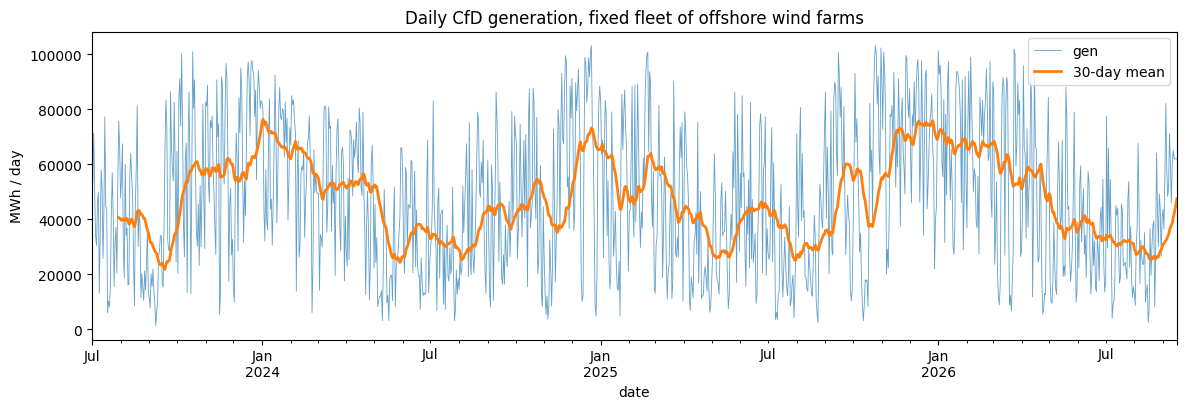

In [ ]:
start = pd.Timestamp("2023-07-01")
end = off["date"].max()

s = summary.reset_index()
stable = s[(s["first"] < start - pd.Timedelta(days=90)) &
           (s["last"] >= end - pd.Timedelta(days=14))]
print(len(stable), "units in the stable fleet")

daily = (off[off["unit"].isin(stable["unit"]) & (off["date"] >= start)]
         .groupby("date")["gen"].sum().to_frame())
print(len(daily), "days,", daily.index.min().date(), "to", daily.index.max().date())

fig, ax = plt.subplots(figsize=(14, 4))
daily["gen"].plot(ax=ax, lw=0.6, alpha=0.7)
daily["gen"].rolling(30).mean().plot(ax=ax, lw=2, label="30-day mean")
ax.set_ylabel("MWh / day"); ax.legend()
ax.set_title("Daily CfD generation, fixed fleet of offshore wind farms")
plt.show()

Each winter's 30-day mean peaks at about 70,000 to 75,000 MWh, and each summer's bottoms out at about 25,000 to 35,000. The levels repeat year to year, so the fixed-fleet approach worked.

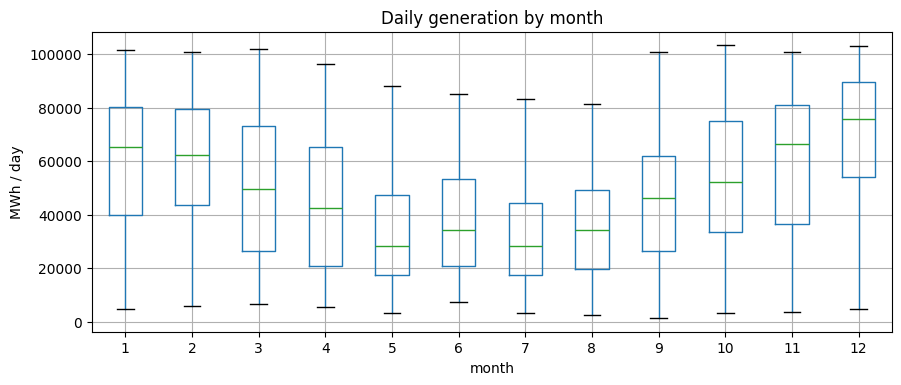

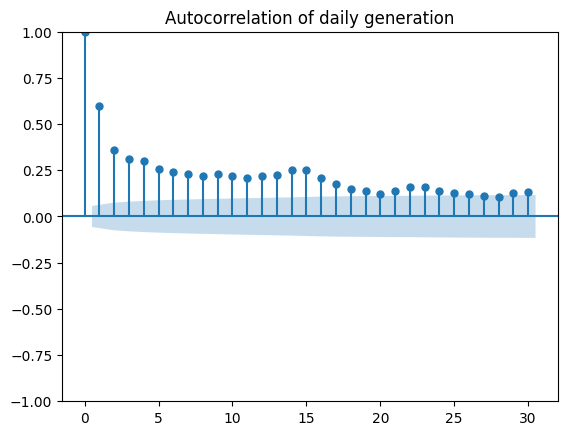

In [ ]:
# Seasonality by month
daily["month"] = daily.index.month
daily.boxplot(column="gen", by="month", figsize=(10, 4))
plt.suptitle(""); plt.title("Daily generation by month"); plt.ylabel("MWh / day")
plt.show()

# How long does "today" predict "tomorrow"?
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(daily["gen"], lags=30)
plt.title("Autocorrelation of daily generation")
plt.show()

daily = daily.drop(columns="month")
daily.to_csv("/content/drive/MyDrive/daily_offshore_fleet.csv")

Generation has strong short-term persistence (lag-1 autocorrelation ≈ 0.6) that decays within two days, with a weaker seasonal component persisting beyond. Within-month variability far exceeds the seasonal signal, motivating the use of weather inputs.

In [ ]:
farm_of = {"Burbo": "Burbo Bank", "Dudgeon": "Dudgeon", "Walney": "Walney Ext",
           "Beatrice": "Beatrice", "Hornsea Offshore": "Hornsea 1",
           "EA 1": "East Anglia 1", "Triton": "Triton Knoll"}

st = stable.copy()
st["farm"] = st["name"].apply(lambda n: next(v for k, v in farm_of.items() if k in n))
weights = st.groupby("farm")["max_daily_MWh"].sum()
weights = weights / weights.sum()
weights.sort_values(ascending=False)

,max_daily_MWh
farm,
Hornsea 1,0.260173
Triton Knoll,0.178710
East Anglia 1,0.152883
Walney Ext,0.144714
Beatrice,0.121344
Dudgeon,0.087203
Burbo Bank,0.054973


In [ ]:
sites = {"Burbo Bank": (53.48, -3.27), "Dudgeon": (53.25, 1.38),
         "Walney Ext": (54.08, -3.73), "Beatrice": (58.25, -3.00),
         "Hornsea 1": (53.88, 1.92), "East Anglia 1": (52.23, 2.49),
         "Triton Knoll": (53.50, 0.80)}

hourly = {}
for farm, (lat, lon) in sites.items():
    r = requests.get("https://archive-api.open-meteo.com/v1/archive", params={
        "latitude": lat, "longitude": lon,
        "start_date": str(daily.index.min().date()),
        "end_date": str(daily.index.max().date()),
        "hourly": "wind_speed_100m", "wind_speed_unit": "ms",
        "timezone": "Europe/London"})
    r.raise_for_status()
    h = r.json()["hourly"]
    hourly[farm] = pd.Series(h["wind_speed_100m"], index=pd.to_datetime(h["time"]))
    print(farm, "done")

wind_h = pd.DataFrame(hourly)
wind_h.to_csv("/content/drive/MyDrive/wind_hourly.csv")
wind_h.describe().round(1)

Burbo Bank done
Dudgeon done
Walney Ext done
Beatrice done
Hornsea 1 done
East Anglia 1 done
Triton Knoll done


,Burbo Bank,Dudgeon,Walney Ext,Beatrice,Hornsea 1,East Anglia 1,Triton Knoll
count,28176.0,28176.0,28176.0,28176.0,28176.0,28176.0,28176.0
mean,7.4,9.2,9.6,9.4,9.6,9.4,9.3
std,3.6,4.1,4.6,4.5,4.3,4.3,4.1
min,0.0,0.1,0.1,0.0,0.1,0.0,0.0
25%,4.9,6.2,6.3,6.0,6.4,6.3,6.4
50%,7.0,8.9,9.2,9.2,9.2,9.1,9.0
75%,9.5,11.8,12.7,12.3,12.3,12.2,12.0
max,27.5,26.0,30.7,34.9,28.3,29.1,27.5


Sanity-checked each site's wind distribution; moved one site offshore after its grid cell showed coastal wind speeds. Burbo Bank. Its average wind is 7.4 m/s, while every other farm is between 9.2 and 9.6. Weather data comes in grid cells about 25 to 30 km across. I probably put it in a cell that includes the Wirral coastline, where land slows the wind down.

In [ ]:
sites["Burbo Bank"] = (53.52, -3.45)

In [ ]:
w = wind_h[weights.index]
daily_wind = pd.DataFrame({
    "wind": (w.resample("D").mean() * weights).sum(axis=1),
    "wind3": ((w ** 3).resample("D").mean() * weights).sum(axis=1),
})
daily = daily.drop(columns=["wind", "wind3"], errors="ignore").join(daily_wind, how="inner")
print(daily.shape)
daily.head()

(1174, 3)


,gen,wind,wind3
date,,,
2023-07-01,76390.609,11.273206,1650.456335
2023-07-02,53487.251,12.374393,2014.599301
2023-07-03,71363.160,11.016670,1484.753242
2023-07-04,49859.310,8.895813,954.768749
2023-07-05,33827.659,7.914184,805.824256


In [ ]:
w = wind_h[weights.index]
daily_wind = pd.DataFrame({
    "wind": (w.resample("D").mean() * weights).sum(axis=1),
    "wind3": ((w ** 3).resample("D").mean() * weights).sum(axis=1),
})
daily = daily.drop(columns=["wind", "wind3"], errors="ignore").join(daily_wind, how="inner")
print(daily.shape)
daily.head()

(1174, 3)


,gen,wind,wind3
date,,,
2023-07-01,76390.609,11.273206,1650.456335
2023-07-02,53487.251,12.374393,2014.599301
2023-07-03,71363.160,11.016670,1484.753242
2023-07-04,49859.310,8.895813,954.768749
2023-07-05,33827.659,7.914184,805.824256


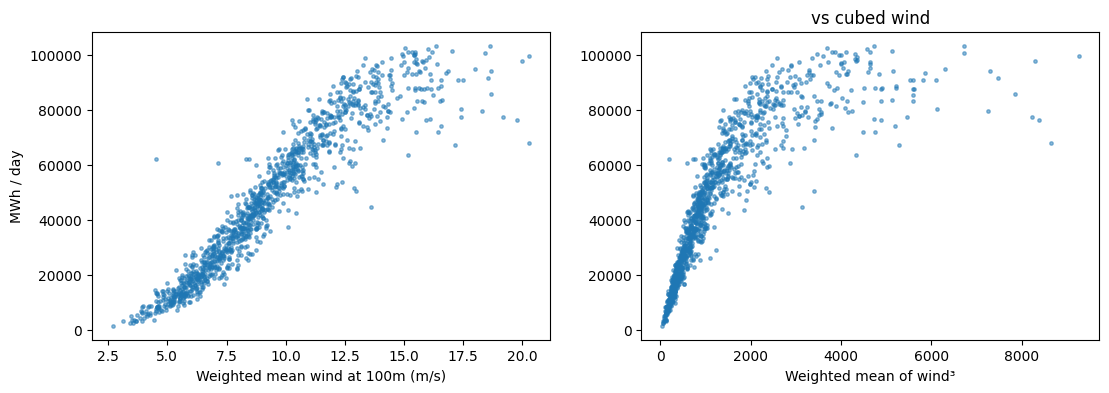

        gen  wind  wind3
gen    1.00  0.94   0.81
wind   0.94  1.00   0.93
wind3  0.81  0.93   1.00


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].scatter(daily["wind"], daily["gen"], s=6, alpha=0.5)
ax[0].set_xlabel("Weighted mean wind at 100m (m/s)"); ax[0].set_ylabel("MWh / day")
ax[1].scatter(daily["wind3"], daily["gen"], s=6, alpha=0.5)
ax[1].set_xlabel("Weighted mean of wind³"); ax[1].set_title("vs cubed wind")
plt.show()
print(daily[["gen", "wind", "wind3"]].corr().round(2))

Wind speed explains the data extremely well. The correlation between mean wind and generation is 0.94, against 0.6 for yesterday's generation. The theoretical cubic relationship held only below rated speed; at fleet level, mean wind speed was the stronger predictor

There are also two odd points: about 62,000 MWh at only 4.5 and 7 m/s, well above the curve.

In [ ]:
daily["expected_gap"] = daily["gen"] - daily["gen"].rolling(1).mean()  # placeholder column
odd = daily[(daily["wind"] < 8) & (daily["gen"] > 55000)]
print(odd[["gen", "wind"]])
daily = daily.drop(columns="expected_gap")

                  gen      wind
date                           
2026-09-11  60487.763  7.140022
2026-09-13  62005.851  4.539837


In [ ]:
for d in odd.index:
    print(d.date())
    print(off[off["date"] == d][["name", "gen"]].sort_values("gen", ascending=False).head(8), "\n")

2026-09-11
                                               name       gen
49652                     Hornsea Project 2 Phase 2  6597.054
48749                     Hornsea Project 2 Phase 1  6524.972
104320           Hornsea Offshore Wind Farm Phase 2  6323.149
50555                     Hornsea Project 2 Phase 3  5997.825
101959           Hornsea Offshore Wind Farm Phase 1  5699.846
106316           Hornsea Offshore Wind Farm Phase 3  5665.426
58450       Triton Knoll Offshore Wind Farm Phase 3  5113.359
113601  Walney Extension Offshore Wind Farm Phase 1  4960.795 

2026-09-13
                                               name       gen
49654                     Hornsea Project 2 Phase 2  6469.248
50557                     Hornsea Project 2 Phase 3  6451.202
48751                     Hornsea Project 2 Phase 1  6392.856
104322           Hornsea Offshore Wind Farm Phase 2  6269.556
101961           Hornsea Offshore Wind Farm Phase 1  6142.246
106318           Hornsea Offshore Wind Farm Ph

Two anomalous days (high generation, low wind) fell in the final week of the data; as recent settlement and reanalysis data may be provisional, the analysis window was ended on 31 August 2026

In [ ]:
daily = daily.loc[:"2026-08-31"]
print(len(daily), "days,", daily.index.min().date(), "to", daily.index.max().date())

1158 days, 2023-07-01 to 2026-08-31


In [ ]:
daily.to_csv("/content/drive/MyDrive/daily_with_wind.csv")

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Storm feature: weighted share of hours above typical cut-out speed (25 m/s)
storm = ((wind_h[weights.index] > 25).resample("D").mean() * weights).sum(axis=1)
daily["storm_share"] = storm.reindex(daily.index)

# Calendar and lag features
doy = daily.index.dayofyear
daily["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)
daily["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)
daily["wind2"] = daily["wind"] ** 2
daily["gen_lag1"] = daily["gen"].shift(1)
daily["gen_lag7"] = daily["gen"].shift(7)
daily["month"] = daily.index.month
daily = daily.dropna()

train = daily.loc[:"2025-08-31"].copy()
test = daily.loc["2025-09-01":].copy()
print(f"Train: {len(train)} days ({train.index.min().date()} to {train.index.max().date()})")
print(f"Test:  {len(test)} days ({test.index.min().date()} to {test.index.max().date()})")
print("Storm days in data:", (daily["storm_share"] > 0).sum())

Train: 786 days (2023-07-08 to 2025-08-31)
Test:  365 days (2025-09-01 to 2026-08-31)
Storm days in data: 33


In [ ]:
def score(y, pred):
    return {"MAE": mean_absolute_error(y, pred),
            "RMSE": np.sqrt(mean_squared_error(y, pred))}

results = {}
results["Persistence (yesterday)"] = score(test["gen"], test["gen_lag1"])
results["Same day last week"] = score(test["gen"], test["gen_lag7"])

clim = train.groupby("month")["gen"].mean()
results["Climatology (monthly mean)"] = score(test["gen"], test["month"].map(clim))

pd.DataFrame(results).T.round(0)

,MAE,RMSE
Persistence (yesterday),18932.0,24268.0
Same day last week,27893.0,34724.0
Climatology (monthly mean),20935.0,25199.0


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor

models = {
    "Linear: wind only": (LinearRegression(), ["wind"]),
    "Linear: wind + wind²": (LinearRegression(), ["wind", "wind2"]),
    "Gradient boosting": (HistGradientBoostingRegressor(random_state=0),
                          ["wind", "wind3", "storm_share", "doy_sin", "doy_cos", "gen_lag1"]),
}

cap = train["gen"].max()
for name, (model, feats) in models.items():
    model.fit(train[feats], train["gen"])
    pred = np.clip(model.predict(test[feats]), 0, cap)
    test[name] = pred
    results[name] = score(test["gen"], pred)

res = pd.DataFrame(results).T
res["MAE % of mean"] = 100 * res["MAE"] / test["gen"].mean()
res["Skill vs persistence"] = 1 - res["MAE"] / res.loc["Persistence (yesterday)", "MAE"]
res.sort_values("MAE").round(2)

,MAE,RMSE,MAE % of mean,Skill vs persistence
Gradient boosting,5508.79,7277.82,10.74,0.71
Linear: wind + wind²,6364.73,8101.42,12.41,0.66
Linear: wind only,7037.65,8835.88,13.72,0.63
Persistence (yesterday),18932.02,24267.93,36.91,0.00
Climatology (monthly mean),20934.73,25199.26,40.81,-0.11
Same day last week,27893.33,34723.74,54.38,-0.47


In [ ]:
from sklearn.inspection import permutation_importance
gb, feats = models["Gradient boosting"]
imp = permutation_importance(gb, test[feats], test["gen"], n_repeats=10,
                             random_state=0, scoring="neg_mean_absolute_error")
pd.Series(imp.importances_mean, index=feats).sort_values(ascending=False).round(0)

,0
wind,23146.0
wind3,3099.0
doy_cos,932.0
doy_sin,142.0
gen_lag1,-18.0
storm_share,-26.0


Best model: Gradient boosting


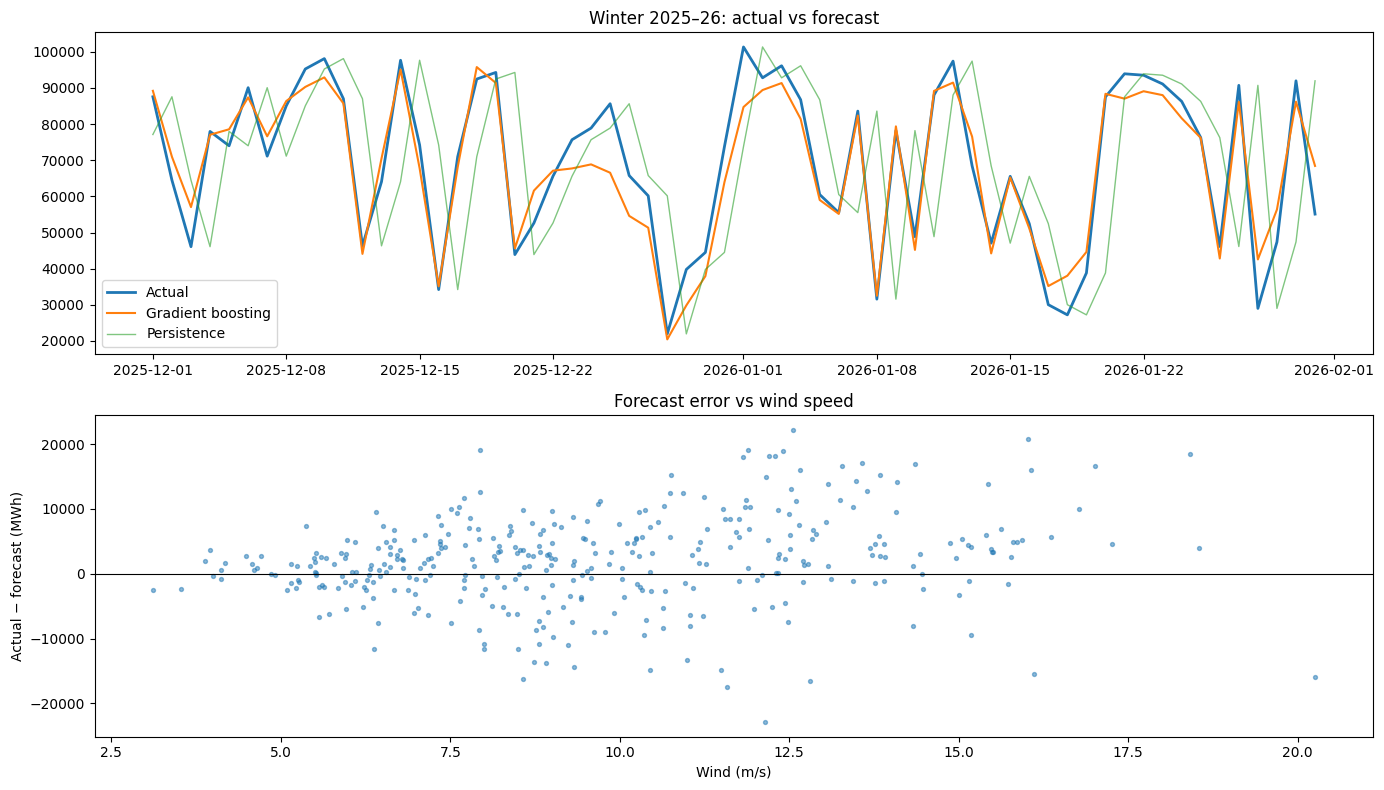

                 gen  Gradient boosting  wind  storm_share
date                                                      
2026-06-13   52983.0            75855.0  12.0          0.0
2026-03-28   89740.0            67513.0  13.0          0.0
2026-03-24  101951.0            81198.0  16.0          0.0
2025-12-25   85642.0            66546.0  12.0          0.0
2026-05-10   48957.0            29873.0   8.0          0.0


In [ ]:
best = res["MAE"].idxmin()
print("Best model:", best)

fig, ax = plt.subplots(2, 1, figsize=(14, 8))
window = test.loc["2025-12-01":"2026-01-31"]
ax[0].plot(window.index, window["gen"], label="Actual", lw=2)
ax[0].plot(window.index, window[best], label=best, lw=1.5)
ax[0].plot(window.index, window["gen_lag1"], label="Persistence", lw=1, alpha=0.6)
ax[0].set_title("Winter 2025–26: actual vs forecast"); ax[0].legend()

test["error"] = test["gen"] - test[best]
ax[1].scatter(test["wind"], test["error"], s=8, alpha=0.5)
ax[1].axhline(0, color="k", lw=0.8)
ax[1].set_xlabel("Wind (m/s)"); ax[1].set_ylabel("Actual − forecast (MWh)")
ax[1].set_title("Forecast error vs wind speed")
plt.tight_layout(); plt.show()

print(test.loc[test["error"].abs().nlargest(5).index, ["gen", best, "wind", "storm_share"]].round(0))

In [ ]:
bins = pd.cut(daily["wind"], [0, 6, 8, 10, 12, 14, 25])
for name, part in [("train", train), ("test", test)]:
    part = part.copy()
    part["pred"] = np.clip(models["Gradient boosting"][0].predict(part[models["Gradient boosting"][1]]), 0, cap)
    part["err"] = part["gen"] - part["pred"]
    print(name, part.groupby(bins.reindex(part.index), observed=True)["err"].mean().round(0).to_dict())

train {Interval(0, 6, closed='right'): -13.0, Interval(6, 8, closed='right'): -14.0, Interval(8, 10, closed='right'): 41.0, Interval(10, 12, closed='right'): -10.0, Interval(12, 14, closed='right'): -34.0, Interval(14, 25, closed='right'): 9.0}
test {Interval(0, 6, closed='right'): 289.0, Interval(6, 8, closed='right'): 1664.0, Interval(8, 10, closed='right'): -92.0, Interval(10, 12, closed='right'): 2442.0, Interval(12, 14, closed='right'): 5366.0, Interval(14, 25, closed='right'): 4318.0}


In [ ]:
for d in ["2026-06-13", "2026-03-28"]:
    day = off[off["date"] == d]
    print(d, "| mean ref price: £", round(day["ref_price"].mean(), 1),
          "| mean capture price: £", round(day["capture_price"].mean(), 1))
print("Typical test-year ref price: £", round(off[off["date"] >= "2025-09-01"]["ref_price"].mean(), 1))

2026-06-13 | mean ref price: £ 27.5 | mean capture price: £ 33.6
2026-03-28 | mean ref price: £ 60.8 | mean capture price: £ 53.6
Typical test-year ref price: £ 92.4


In [ ]:
d = daily.copy()
d["year"] = np.where(d.index < "2024-09-01", "2023–24",
             np.where(d.index < "2025-09-01", "2024–25", "2025–26"))
d["wind_band"] = pd.cut(d["wind"], [0, 8, 10, 12, 14, 25])
print(d.pivot_table(index="wind_band", columns="year", values="gen",
                    aggfunc="mean", observed=True).round(0))

year       2023–24  2024–25  2025–26
wind_band                           
(0, 8]     19900.0  20040.0  21689.0
(8, 10]    45128.0  45520.0  45291.0
(10, 12]   62231.0  67593.0  67366.0
(12, 14]   75580.0  81885.0  83813.0
(14, 25]   84559.0  90992.0  92956.0


In [ ]:
windy = daily[daily["wind"] > 12].index
w_off = off[off["date"].isin(windy) & off["unit"].isin(stable["unit"])].copy()
w_off["farm"] = w_off["name"].apply(lambda n: next(v for k, v in farm_of.items() if k in n))
w_off["year"] = np.where(w_off["date"] < "2024-09-01", "2023–24",
                 np.where(w_off["date"] < "2025-09-01", "2024–25", "2025–26"))
print(w_off.groupby(["farm", "year"])["gen"].sum().unstack()
      .div(w_off.groupby("year")["date"].nunique()).round(0))

year           2023–24  2024–25  2025–26
farm                                    
Beatrice        7901.0   8956.0   9164.0
Burbo Bank      4853.0   4469.0   4245.0
Dudgeon         7921.0   8170.0   8304.0
East Anglia 1  12328.0  13610.0  13854.0
Hornsea 1      19461.0  24402.0  24636.0
Triton Knoll   15466.0  13767.0  15545.0
Walney Ext     11697.0  12250.0  11783.0


In [ ]:
feats_lean = ["wind", "wind3", "doy_sin", "doy_cos"]

# Lean model, trained on both years
gb_lean = HistGradientBoostingRegressor(random_state=0).fit(train[feats_lean], train["gen"])
pred = np.clip(gb_lean.predict(test[feats_lean]), 0, cap)

# Lean model, trained on 2024–25 only
recent = train.loc["2024-09-01":]
gb_recent = HistGradientBoostingRegressor(random_state=0).fit(recent[feats_lean], recent["gen"])
pred_r = np.clip(gb_recent.predict(test[feats_lean]), 0, cap)

print("Full model (6 features, both years):", round(res.loc["Gradient boosting", "MAE"]))
print("Lean model (4 features, both years):", round(mean_absolute_error(test["gen"], pred)))
print("Lean model (4 features, 2024–25 only):", round(mean_absolute_error(test["gen"], pred_r)))

Full model (6 features, both years): 5509
Lean model (4 features, both years): 5615
Lean model (4 features, 2024–25 only): 4905


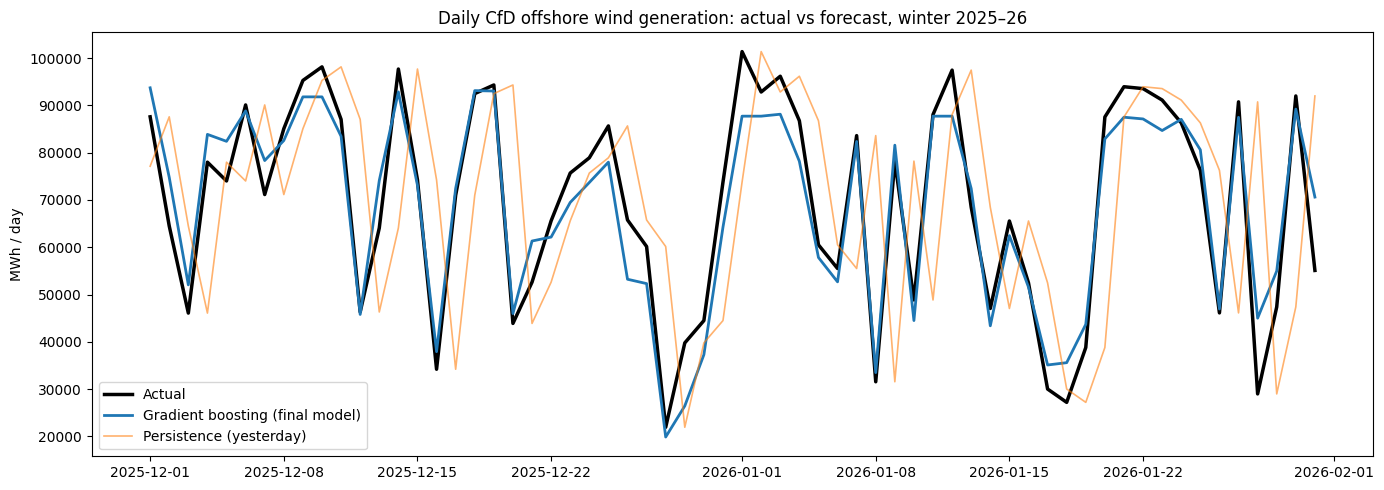

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [64]:
test["Final model"] = pred_r
window = test.loc["2025-12-01":"2026-01-31"]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(window.index, window["gen"], label="Actual", lw=2.5, color="black")
ax.plot(window.index, window["Final model"], label="Gradient boosting (final model)", lw=2)
ax.plot(window.index, window["gen_lag1"], label="Persistence (yesterday)", lw=1.2, alpha=0.6)
ax.set_ylabel("MWh / day")
ax.set_title("Daily CfD offshore wind generation: actual vs forecast, winter 2025–26")
ax.legend()
plt.tight_layout()
plt.savefig("winter_forecast.png", dpi=150, bbox_inches="tight")
plt.show()

from google.colab import files
files.download("winter_forecast.png")

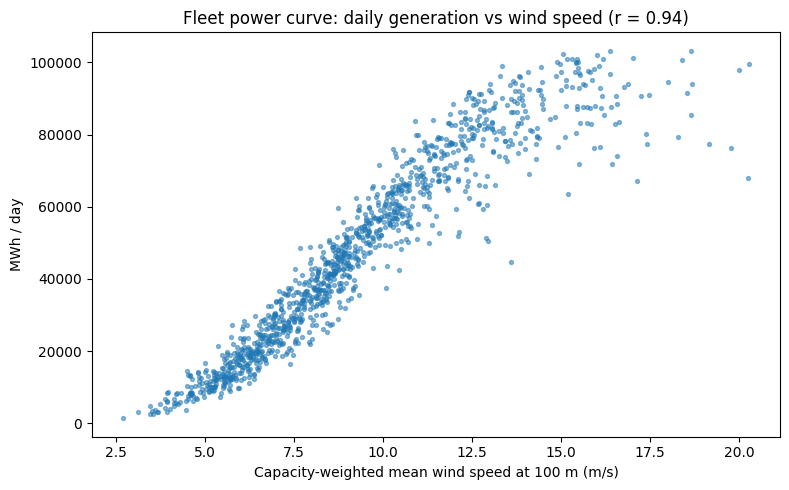

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [65]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(daily["wind"], daily["gen"], s=8, alpha=0.5)
ax.set_xlabel("Capacity-weighted mean wind speed at 100 m (m/s)")
ax.set_ylabel("MWh / day")
ax.set_title("Fleet power curve: daily generation vs wind speed (r = 0.94)")
plt.tight_layout()
plt.savefig("power_curve.png", dpi=150, bbox_inches="tight")
plt.show()

files.download("power_curve.png")